### Name: Pranish Bhuju
### Student ID: 26140506
### Module Code: CMP4294


## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Load Dataset

In [2]:
df = pd.read_csv("gaming_addiction.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (250, 49)


,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,USR000001,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,...,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.0,0.920,1.000
1,USR000002,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,...,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.0,0.515,0.813
2,USR000003,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,...,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.0,0.720,0.947
3,USR000004,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,...,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.0,0.520,0.660
4,USR000005,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,...,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.0,0.585,0.867


## Missing Values

In [3]:
missing = df.isnull().sum()

print(missing[missing > 0])
print("Total Missing Value:",df.isnull().sum().sum())

subscription_status         82
depression_indicator        11
gpa_or_performance_score    10
addiction_severity          16
dtype: int64
Total Missing Value: 119


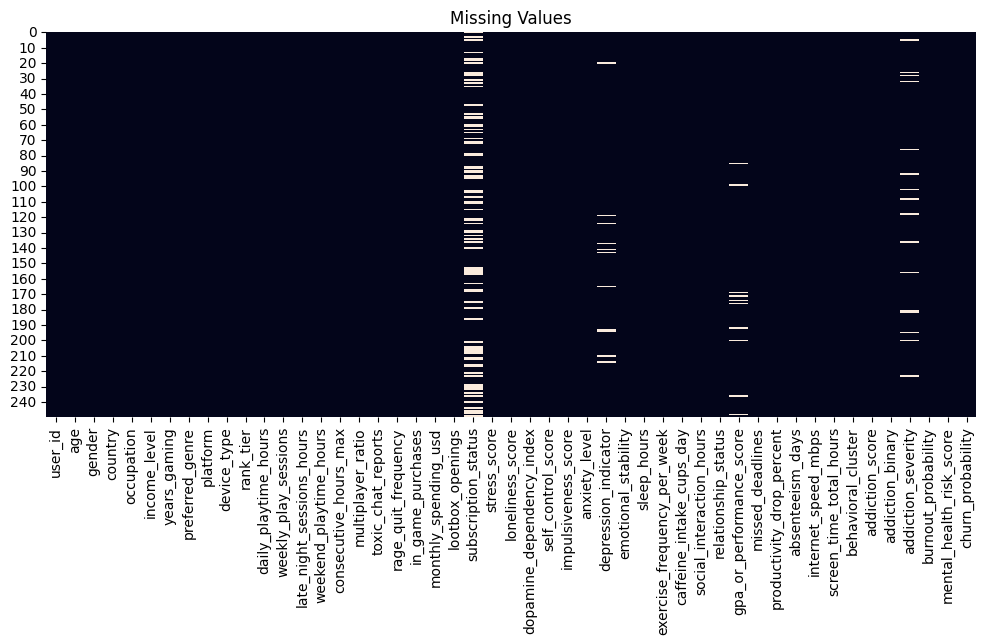

In [4]:
plt.figure(figsize=(12,5))

sns.heatmap(
    df.isnull(),
cbar=False
)

plt.title("Missing Values")
plt.show()

## Duplicate Records

In [5]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


## Data Cleaning


In [6]:
# Remove duplicate rows
df = df.drop_duplicates()

# Remove missing values
df = df.dropna()

# Check the final clean shape
print("Remaining missing values:", df.isnull().sum().sum())
print("Final Cleaned Dataset Shape:", df.shape)

Remaining missing values: 0
Final Cleaned Dataset Shape: (141, 49)


## Descriptive Statistics

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,141.0,22.163121,5.666473,13.000,18.000,22.000,27.000,40.00
years_gaming,141.0,9.624113,5.658797,1.000,6.000,9.000,15.000,25.00
daily_playtime_hours,141.0,6.469504,2.420624,0.500,4.900,6.700,8.200,11.80
weekly_play_sessions,141.0,7.503546,3.381935,1.000,5.000,7.000,10.000,15.00
late_night_sessions_hours,141.0,2.238298,1.110962,0.000,1.400,2.100,3.000,5.20
weekend_playtime_hours,141.0,8.596454,3.723294,0.500,6.000,8.400,10.600,20.00
consecutive_hours_max,141.0,10.318440,4.387215,1.000,7.100,10.800,13.400,19.40
multiplayer_ratio,141.0,0.469362,0.221773,0.000,0.320,0.460,0.630,1.00
toxic_chat_reports,141.0,3.297872,5.714324,0.000,0.000,1.000,3.000,32.00
rage_quit_frequency,141.0,2.134752,2.397081,0.000,0.000,1.000,3.000,10.00


## EDA

## Addiction Severity Distribution

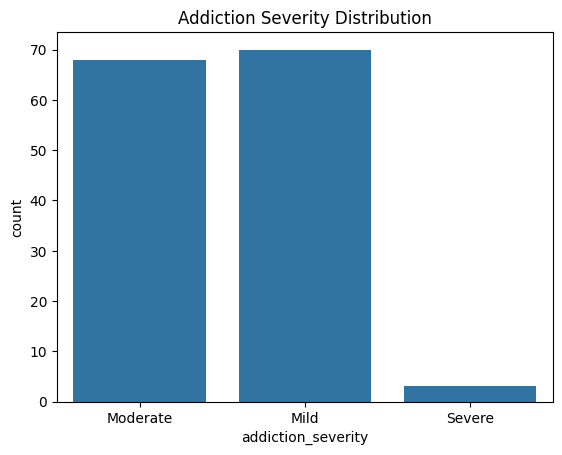

In [8]:
sns.countplot(
    x="addiction_severity",
    data=df
)

plt.title(
    "Addiction Severity Distribution"
)

plt.show()

## Age Distribution

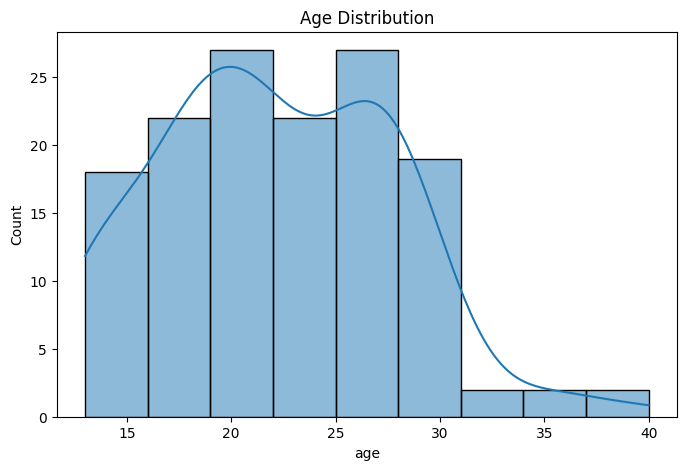

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    kde=True
)

plt.title("Age Distribution")

plt.show()

## Daily Playtime

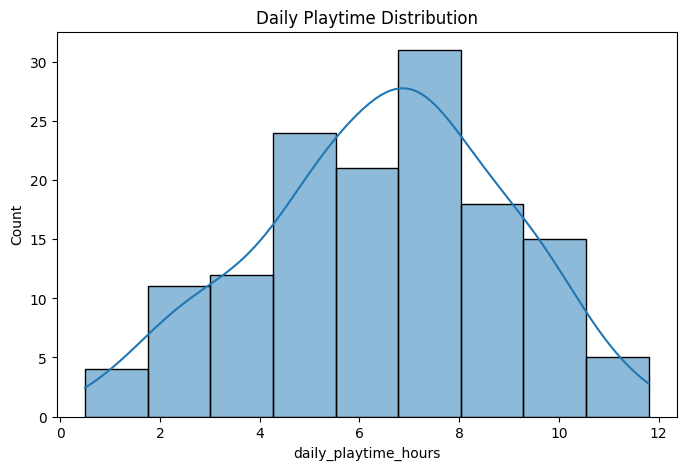

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["daily_playtime_hours"],
    kde=True
)

plt.title(
    "Daily Playtime Distribution"
)

plt.show()

## Playtime vs Addiction Severity

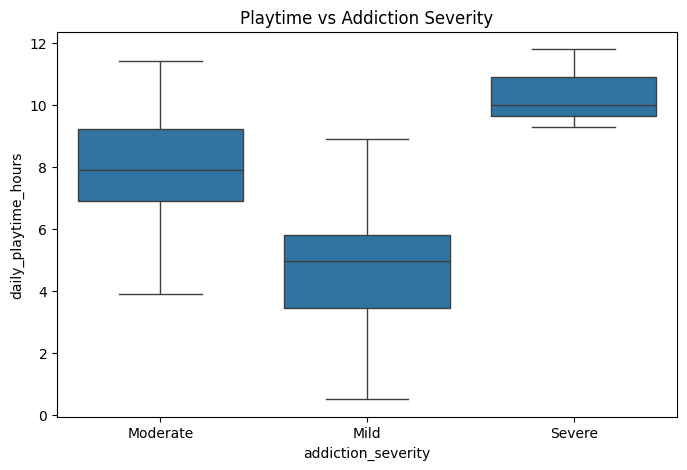

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="addiction_severity",
    y="daily_playtime_hours",
    data=df
)

plt.title(
    "Playtime vs Addiction Severity"
)

plt.show()

## Sleep Hours Distribution

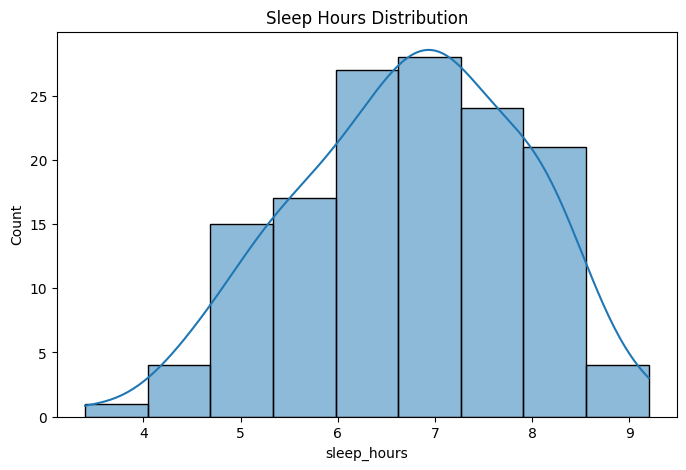

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["sleep_hours"],
    kde=True
)

plt.title(
    "Sleep Hours Distribution"
)

plt.show()

## Stress Score Distribution

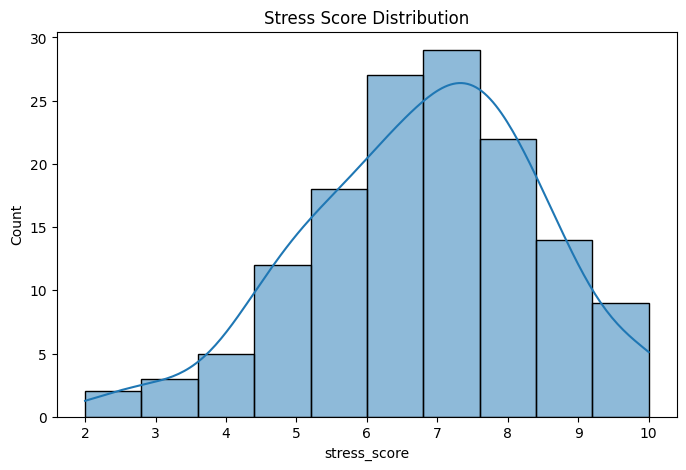

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["stress_score"],
    kde=True
)

plt.title(
    "Stress Score Distribution"
)

plt.show()

## Productivity Drop Distribution

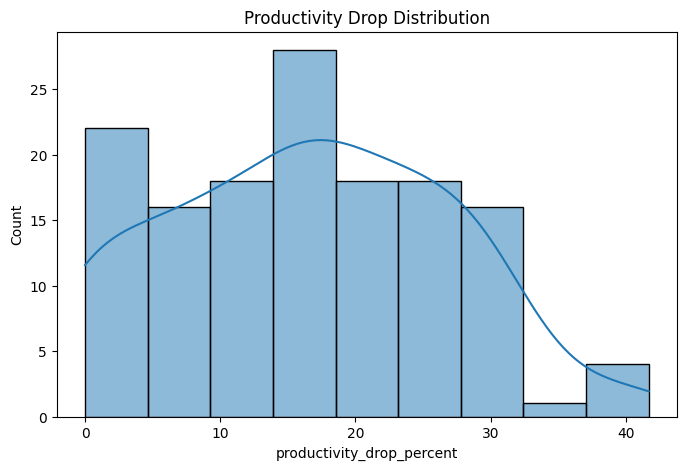

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["productivity_drop_percent"],
    kde=True
)

plt.title(
    "Productivity Drop Distribution"
)

plt.show()

## Encode Categorical Data

In [15]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col].astype(str))

## Correlation Analysis

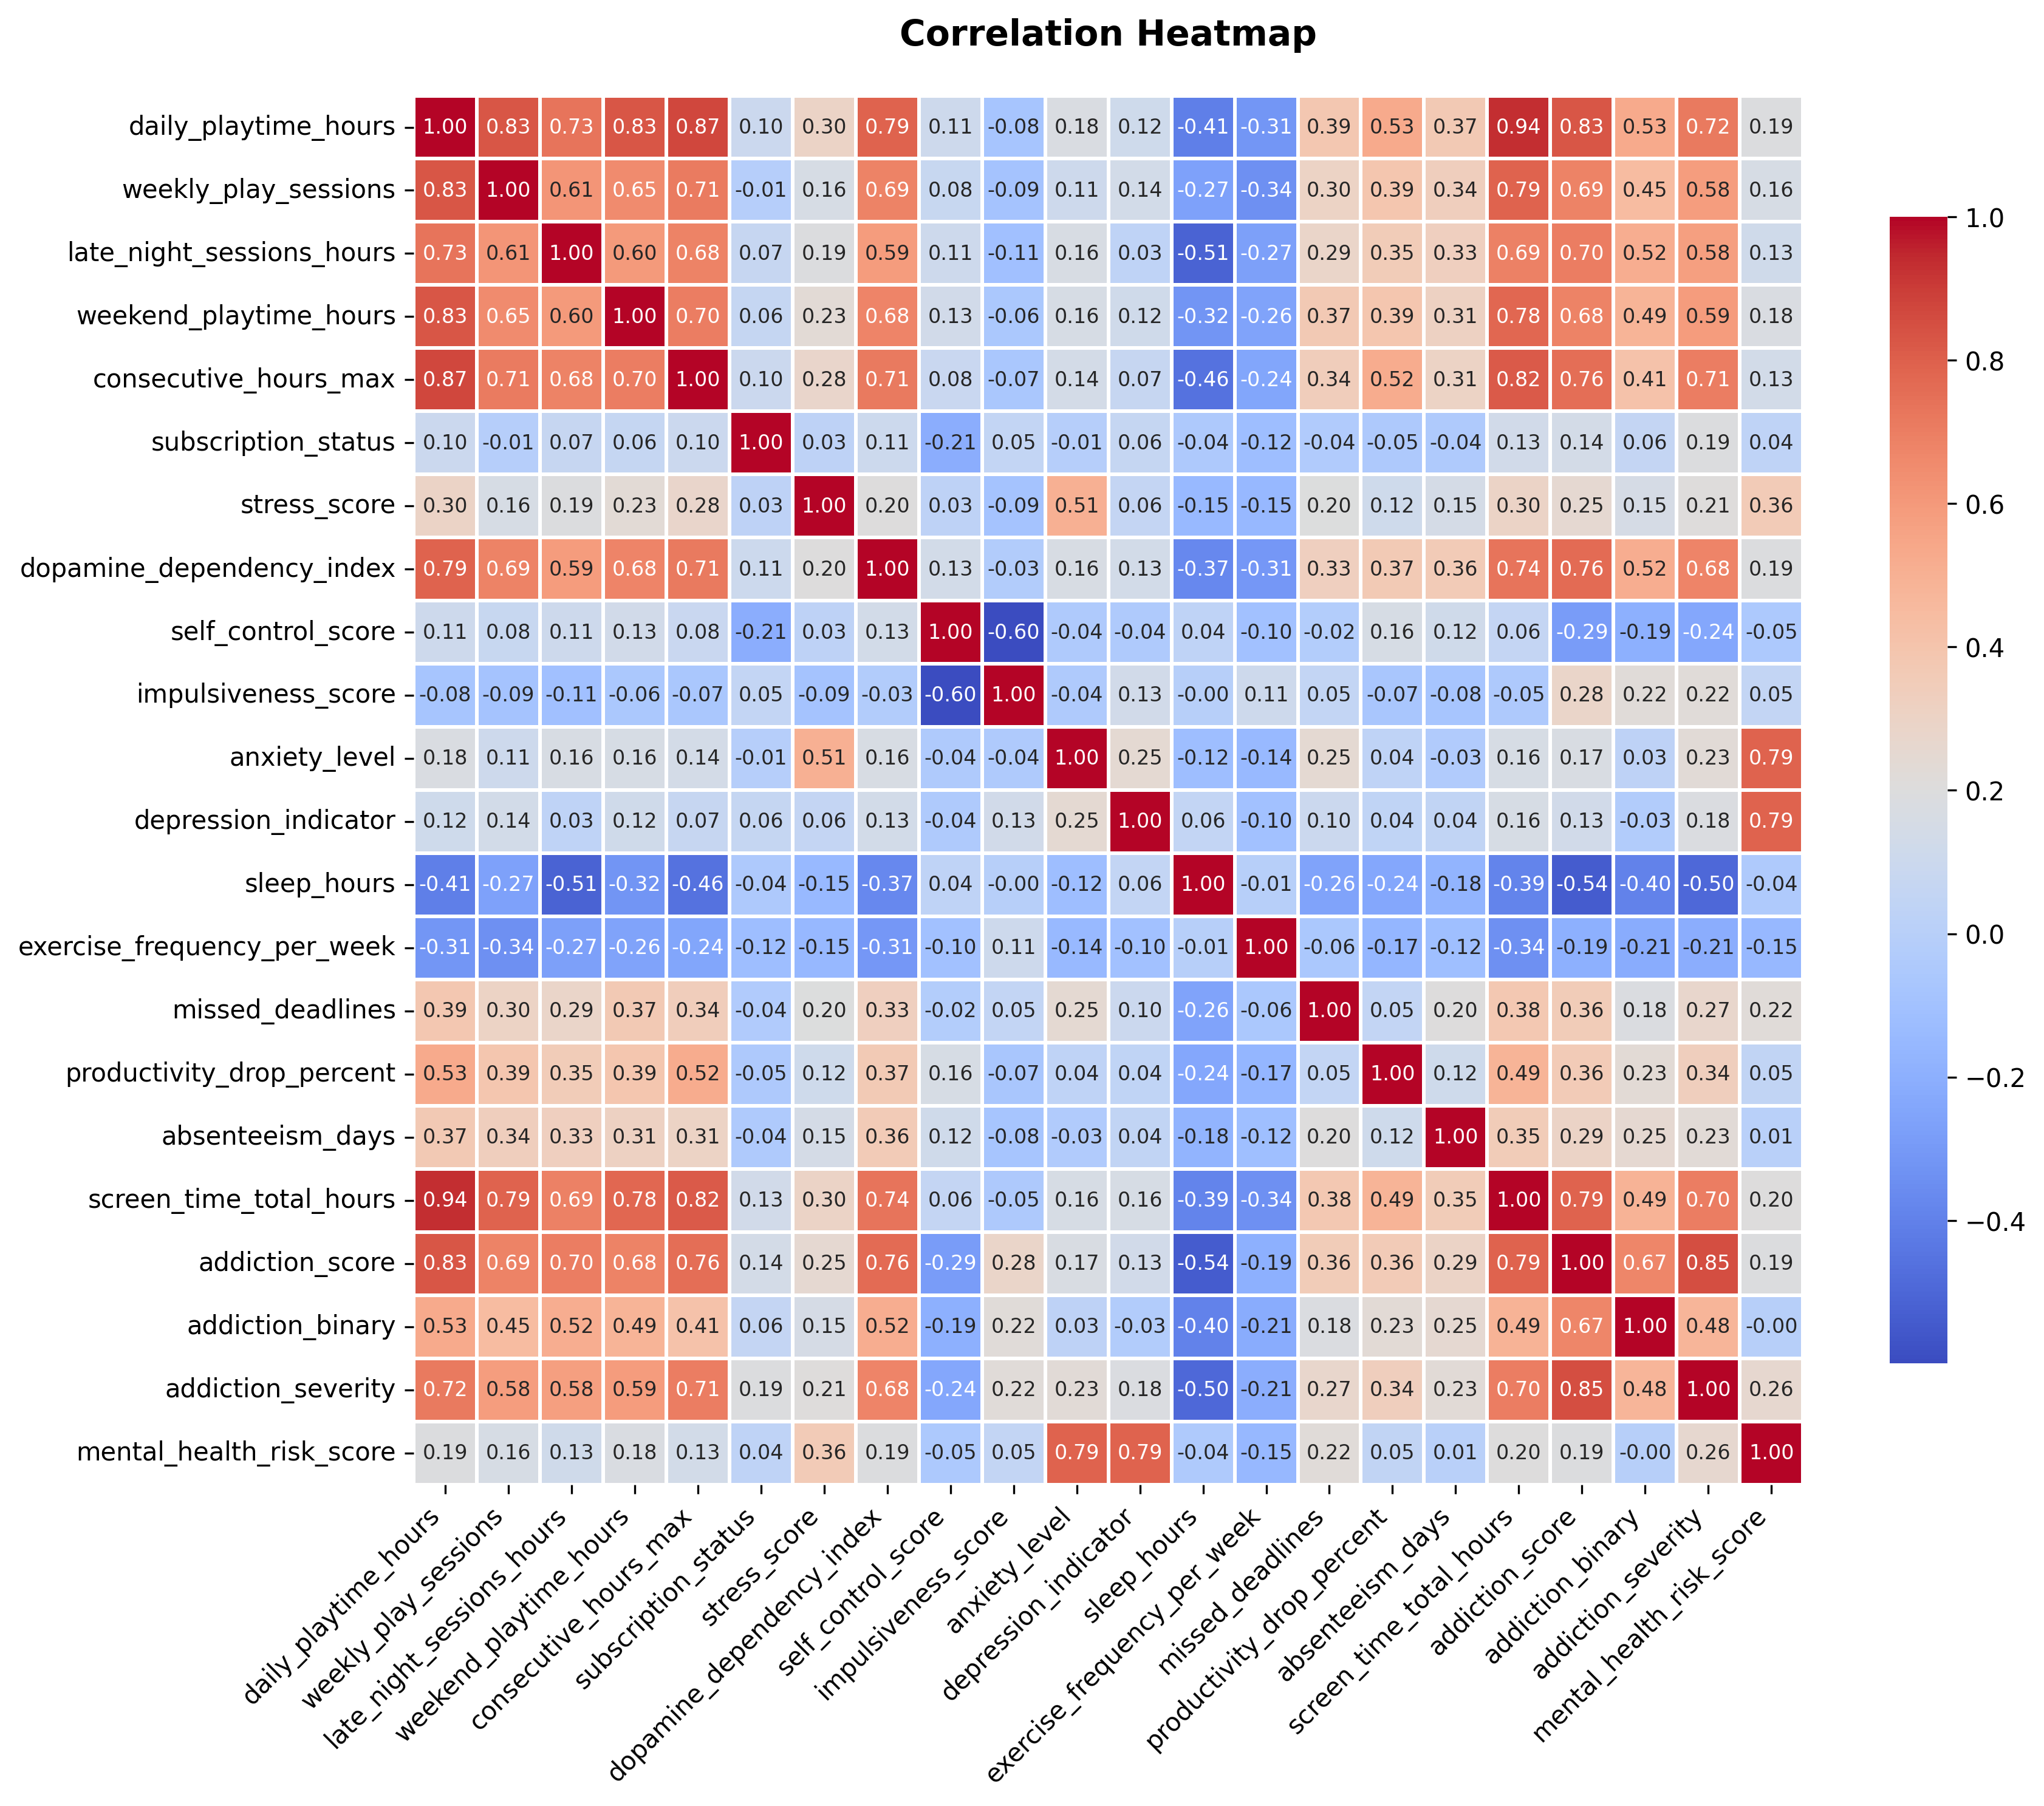

In [16]:

numeric_df = df.select_dtypes(include=[np.number])

# Ensure target exists
target = "addiction_severity"

if target not in numeric_df.columns:
    raise KeyError("Target column 'addiction_severity' not found. Check encoding or dataset.")

# 1. Correlation matrix
corr_matrix = numeric_df.corr()

# 2. Correlation with target variable
target_corr = corr_matrix[target].abs()

# 3. Feature selection threshold
threshold = 0.15

selected_features = target_corr[target_corr >= threshold].index

# 4. Filter correlation matrix
filtered_corr = corr_matrix.loc[selected_features, selected_features]

# 5. Plot heatmap
plt.figure(figsize=(12, 10), dpi=300)

sns.heatmap(
    filtered_corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=1,
    square=True,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Correlation Heatmap",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Define Features and Target

In [17]:
X = df.drop([
    "addiction_severity",
    "addiction_score",
    "addiction_binary",
    "user_id"
], axis=1)

y = df["addiction_severity"]

## Train Test Split (80/20)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 112
Testing set size: 29


## Random Forest Model 

In [19]:
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=2,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42
)

# Train model
model.fit(X_train, y_train)

print("Model Training Completed")

print(
    "Random Forest Trees:",
    len(model.estimators_)
)

Model Training Completed
Random Forest Trees: 500


## Prediction

In [20]:
y_pred = model.predict(X_test)

## Accuracy

In [21]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.896551724137931


## Classification Report

In [22]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.87      0.93      0.90        14
           2       0.00      0.00      0.00         1

    accuracy                           0.90        29
   macro avg       0.60      0.62      0.61        29
weighted avg       0.87      0.90      0.88        29



## Confusion Matrix

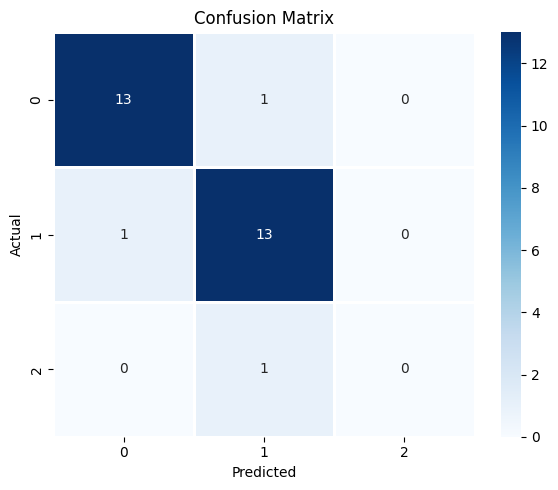

In [23]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.show()

## Top 10 Features

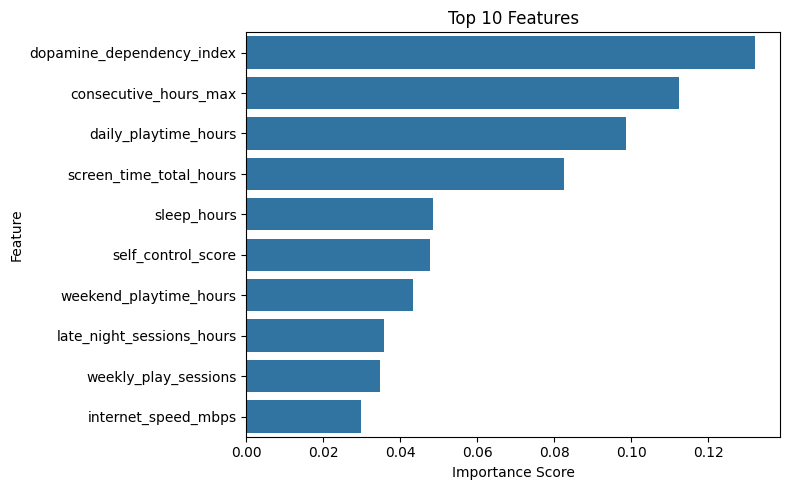

In [ ]:
# Top 10 Features

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

top10 = importance.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features")

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

## Prediction Confidence

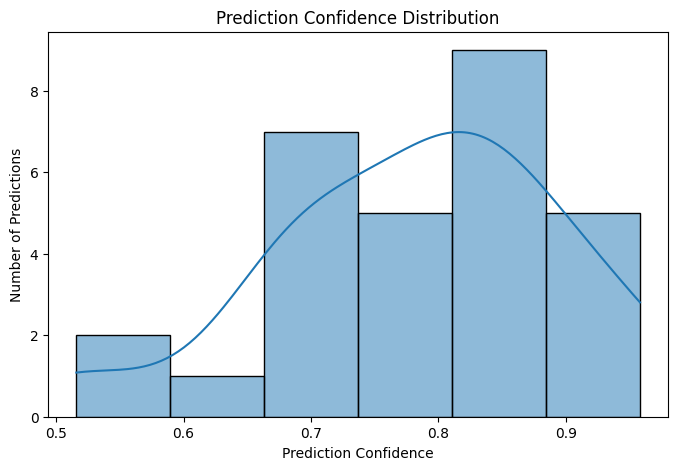

In [ ]:
# Prediction Confidence

# Probability of each class
probs = model.predict_proba(X_test)

# Highest probability for each prediction 
confidence = np.max(probs, axis=1)

plt.figure(figsize=(8,5))

sns.histplot(
    confidence,
    kde=True
)

plt.title(
    "Prediction Confidence Distribution"
)

plt.xlabel(
    "Prediction Confidence"
)

plt.ylabel(
    "Number of Predictions"
)

plt.show()

## Error Analysis

In [ ]:
# Error Analysis

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability": np.round(
        confidence,
        3
    )
})

errors = results[
    results["Actual"] !=
    results["Predicted"]
]

print(
    "Total Misclassified Cases:",
    len(errors)
)

error_rate = (
    len(errors) /
    len(results)
) * 100

print(
    f"Error Rate: {error_rate:.2f}%"
)

errors

Total Misclassified Cases: 3
Error Rate: 10.34%


,Actual,Predicted,Probability
14,2,1,0.832
20,1,0,0.521
28,0,1,0.660


## Model Insights Summary

In [27]:
acc = accuracy_score(
    y_test,
    y_pred
)

avg_confidence = np.mean(
    confidence
)

top_feature = (
    importance.iloc[0]["Feature"]
)

top_feature_score = (
    importance.iloc[0]["Importance"]
)

print("MODEL INSIGHTS SUMMARY")

print(
    f"Model Accuracy: {acc:.2%}"
)

print(
    f"Most Influential Feature: {top_feature}"
)

print(
    f"Feature Importance Score: {top_feature_score:.4f}"
)

print(
    f"Average Prediction Confidence: {avg_confidence:.2%}"
)

if acc >= 0.85:
    performance = "Excellent"
elif acc >= 0.75:
    performance = "Good"
elif acc >= 0.60:
    performance = "Moderate"
else:
    performance = "Needs Improvement"

print(
    f"Overall Model Performance: {performance}"
)

print(
    f"Total Features Used: {X.shape[1]}"
)

print(
    f"Misclassified Cases: {len(errors)}"
)

MODEL INSIGHTS SUMMARY
Model Accuracy: 89.66%
Most Influential Feature: dopamine_dependency_index
Feature Importance Score: 0.1320
Average Prediction Confidence: 78.12%
Overall Model Performance: Excellent
Total Features Used: 45
Misclassified Cases: 3
